# Imports

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import networkx as nx
import seaborn as sns
import matplotlib.pyplot as plt

from utils.config import OUT_DIR, CLUBS_ORDERED
from utils.graph.layout import plot_graph_by_club
SRC_ROOT = Path('').resolve().parents[1]
PARQUET_OUT_DIR = SRC_ROOT / OUT_DIR


# Dataframes loading

## Proceedings

In [2]:
df_proceedings = pd.read_parquet(PARQUET_OUT_DIR / 'proceedings.parquet')

In [3]:
df_proceedings.head()

,sitting,title
0,1,"1. Posiedzenie Sejmu RP w dniach 13, 14, 21, 2..."
1,2,2. Posiedzenie Sejmu RP w dniach 16 i 17 stycz...
2,3,3. Posiedzenie Sejmu RP w dniu 18 stycznia 202...
3,4,4. Posiedzenie Sejmu RP w dniach 25 i 26 stycz...
4,5,"5. Posiedzenie Sejmu RP w dniach 7, 8 i 9 lute..."


## Voting

In [4]:
df_votings = pd.read_parquet(PARQUET_OUT_DIR / 'votings.parquet')

In [5]:
df_votings.head()

,sitting,votingNumber,date,kind,title,topic,yes,no,abstain,totalVoted
0,1,2,2023-11-13T18:02:12,ELECTRONIC,Pkt. 2 Poselskie projekty uchwał w sprawie ust...,Pkt. 2 Poselskie projekty uchwał w sprawie ust...,458,0,0,458
1,1,3,2023-11-13T19:41:22,ELECTRONIC,Pkt. 3 Wybór Wicemarszałków Sejmu RP (druki nr...,Głosowanie nad kandydaturą Posła Krzysztofa Bo...,272,27,153,452
2,1,4,2023-11-13T19:42:14,ELECTRONIC,Pkt. 3 Wybór Wicemarszałków Sejmu RP (druki nr...,Głosowanie nad kandydaturą Posła Włodzimierza ...,250,196,12,458
3,1,5,2023-11-13T19:43:07,ELECTRONIC,Pkt. 3 Wybór Wicemarszałków Sejmu RP (druki nr...,Głosowanie nad kandydaturą Poseł Doroty Niedzi...,257,185,16,458
4,1,6,2023-11-13T19:43:53,ELECTRONIC,Pkt. 3 Wybór Wicemarszałków Sejmu RP (druki nr...,Głosowanie nad kandydaturą Poseł Moniki Wielic...,252,186,18,456


## Votes

In [6]:
df_votes = pd.read_parquet(PARQUET_OUT_DIR / 'votes.parquet')

In [7]:
df_votes.head()

,sitting,votingNumber,MP,club,vote
0,1,2,1,PiS,YES
1,1,2,2,KO,YES
2,1,2,3,PiS,YES
3,1,2,4,PiS,YES
4,1,2,5,PiS,YES


## Members

In [8]:
df_members = pd.read_parquet(PARQUET_OUT_DIR / 'members.parquet')

In [9]:
df_members.head()

,MP,club,firstName,lastName
0,1,PiS,Andrzej,Adamczyk
1,2,KO,Piotr,Adamowicz
2,3,PiS,Adam,Andruszkiewicz
3,4,PiS,Waldemar,Andzel
4,5,PiS,Dorota,Arciszewska-Mielewczyk


# Graph creation

## Sanity check

In [10]:
required_votes_cols = {"sitting", "votingNumber", "MP", "vote"}
required_votings_cols = {"sitting", "votingNumber", "yes", "totalVoted"}
required_members_cols = {"MP", "club"}

missing_votes = required_votes_cols - set(df_votes.columns)
missing_votings = required_votings_cols - set(df_votings.columns)
missing_members = required_members_cols - set(df_members.columns)

if missing_votes or missing_votings or missing_members:
    raise ValueError(
        "Missing required columns: "
        f"votes={sorted(missing_votes)}, "
        f"votings={sorted(missing_votings)}, "
        f"members={sorted(missing_members)}"
    )

## Polarity

In [11]:

polarity_per_voting = df_votings[["sitting", "votingNumber", "yes", "totalVoted"]].copy()
polarity_per_voting = polarity_per_voting[polarity_per_voting["totalVoted"] > 0].copy()
p_yes = polarity_per_voting["yes"] / polarity_per_voting["totalVoted"]
polarity_per_voting["polarity"] = 1 - 2 * (p_yes - 0.5).abs()
polarity_per_voting.head()

,sitting,votingNumber,yes,totalVoted,polarity
0,1,2,458,458,0.000000
1,1,3,272,452,0.796460
2,1,4,250,458,0.908297
3,1,5,257,458,0.877729
4,1,6,252,456,0.894737


## Votes with polarity df

In [12]:

votes_with_polarity = df_votes[["sitting", "votingNumber", "MP", "vote"]].merge(
    polarity_per_voting[["sitting", "votingNumber", "polarity"]],
    on=["sitting", "votingNumber"],
    how="inner",
)
votes_with_polarity.head()

,sitting,votingNumber,MP,vote,polarity
0,1,2,1,YES,0.0
1,1,2,2,YES,0.0
2,1,2,3,YES,0.0
3,1,2,4,YES,0.0
4,1,2,5,YES,0.0


## Merge with itself

In [13]:
pairs = votes_with_polarity.merge(
    votes_with_polarity,
    on=["sitting", "votingNumber"],
    suffixes=("_i", "_j"),
)
pairs = pairs[pairs["MP_i"] < pairs["MP_j"]].copy()
pairs.head()

,sitting,votingNumber,MP_i,vote_i,polarity_i,MP_j,vote_j,polarity_j
1,1,2,1,YES,0.0,2,YES,0.0
2,1,2,1,YES,0.0,3,YES,0.0
3,1,2,1,YES,0.0,4,YES,0.0
4,1,2,1,YES,0.0,5,YES,0.0
5,1,2,1,YES,0.0,6,YES,0.0


## Calculate polarity-weighted agreement score

Let:
- $V$ be the set of all votings,
- $M$ be the set of all members,
- $x_{i,v} \in \{\mathrm{YES}, \mathrm{NO}, \mathrm{ABSTAIN}\}$ be the vote cast by member $i \in M$ in voting $v \in V$.

For each voting $v$, define:

$$
p_v = \frac{\mathrm{yes}_v}{\mathrm{totalVoted}_v},
\qquad
w_v = 1 - 2\left|p_v - \frac{1}{2}\right|.
$$

For each pair $(i,j)$ with $i < j$, over all votings where both members participated ($V_{ij}$):

$$
\mathrm{denom}_{ij} = \sum_{v \in V_{ij}} w_v,
$$

$$
\mathrm{score}_{ij} = \sum_{v \in V_{ij}} w_v \, \mathbf{1}\!\left(x_{i,v} = x_{j,v}\right),
$$

where $\mathbf{1}(\cdot)$ is the indicator function.

Finally, the edge weight is:

$$
\mathrm{weight}_{ij} =
\begin{cases}
\dfrac{\mathrm{score}_{ij}}{\mathrm{denom}_{ij}}, & \text{if } \mathrm{denom}_{ij} > 0, \\
\text{no edge}, & \text{if } \mathrm{denom}_{ij} = 0.
\end{cases}
$$

This matches the implementation: `denom_w = polarity`, `score_w = polarity * (vote_i == vote_j)`, then aggregation by member pair.

In [14]:
pairs["denom_w"] = pairs["polarity_i"]
pairs["score_w"] = pairs["denom_w"] * pairs["vote_i"].eq(pairs["vote_j"]).astype(float)
pairs

,sitting,votingNumber,MP_i,vote_i,polarity_i,MP_j,vote_j,polarity_j,denom_w,score_w
1,1,2,1,YES,0.000000,2,YES,0.000000,0.000000,0.000000
2,1,2,1,YES,0.000000,3,YES,0.000000,0.000000,0.000000
3,1,2,1,YES,0.000000,4,YES,0.000000,0.000000,0.000000
4,1,2,1,YES,0.000000,5,YES,0.000000,0.000000,0.000000
5,1,2,1,YES,0.000000,6,YES,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
40650658,5,29,459,YES,0.070093,461,YES,0.070093,0.070093,0.070093
40650852,5,29,459,YES,0.070093,462,YES,0.070093,0.070093,0.070093
40651075,5,29,459,YES,0.070093,460,YES,0.070093,0.070093,0.070093
40651086,5,29,460,YES,0.070093,461,YES,0.070093,0.070093,0.070093


In [15]:


edge_stats = pairs.groupby(["MP_i", "MP_j"], as_index=False).agg(
    score=("score_w", "sum"),
    denom=("denom_w", "sum"),
    
) 
edge_stats = edge_stats[edge_stats["denom"] > 0].copy()
edge_stats.head()

,MP_i,MP_j,score,denom
0,1,2,3.955261,102.975658
1,1,3,103.933771,108.423595
2,1,4,110.674144,112.759979
3,1,5,102.531470,103.961203
4,1,6,100.329325,105.350839


## Calculate the weight

In [16]:
edge_stats = edge_stats[edge_stats["denom"] > 0].copy()
edge_stats["weight"] = edge_stats["score"] / edge_stats["denom"]
edge_stats

,MP_i,MP_j,score,denom,weight
0,1,2,3.955261,102.975658,0.038410
1,1,3,103.933771,108.423595,0.958590
2,1,4,110.674144,112.759979,0.981502
3,1,5,102.531470,103.961203,0.986247
4,1,6,100.329325,105.350839,0.952335
...,...,...,...,...,...
106476,459,461,2.840255,40.016371,0.070977
106477,459,462,10.162016,10.162016,1.000000
106478,460,461,2.747349,37.373766,0.073510
106479,460,462,9.171052,9.171052,1.000000


## Add members' clubs to the graph

In [17]:
members_nodes = df_members[["MP", "club"]].drop_duplicates(subset=["MP"]).copy()

In [18]:


G = nx.Graph()
for row in members_nodes.itertuples(index=False):
    G.add_node(int(row.MP), club=row.club)

In [19]:
for row in edge_stats.itertuples(index=False):
    G.add_edge(
        int(row.MP_i),
        int(row.MP_j),
        weight=float(row.weight)
    )

graph_stats = {
    "nodes": G.number_of_nodes(),
    "edges": G.number_of_edges(),
    "weight_min": float(edge_stats["weight"].min()) if not edge_stats.empty else None,
    "weight_mean": float(edge_stats["weight"].mean()) if not edge_stats.empty else None,
    "weight_max": float(edge_stats["weight"].max()) if not edge_stats.empty else None,
}

graph_stats

{'nodes': 498,
 'edges': 106481,
 'weight_min': 0.0,
 'weight_mean': 0.4986811203781993,
 'weight_max': 1.0}

# Visualizing the weights

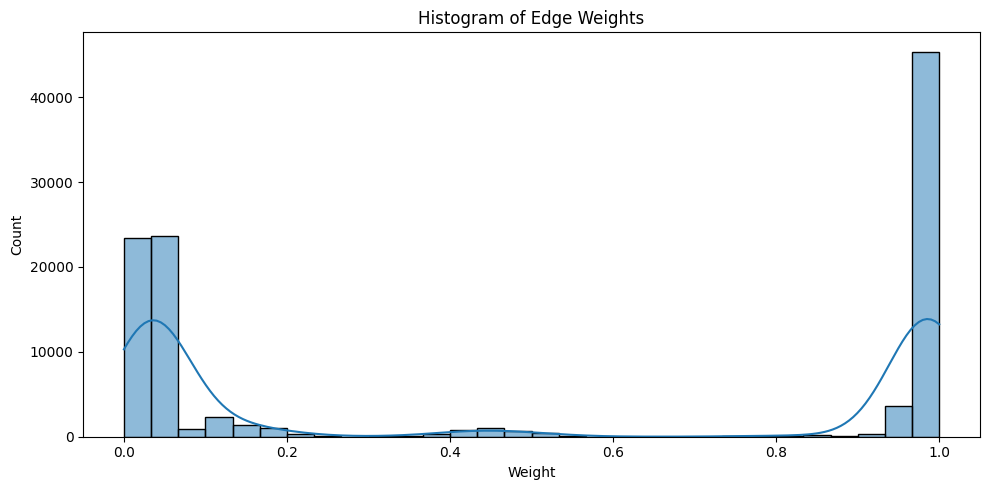

In [20]:
plt.figure(figsize=(10, 5))
sns.histplot(edge_stats["weight"], bins=30, kde=True)
plt.title("Histogram of Edge Weights")
plt.xlabel("Weight")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Sparsing the graph with threshold

In [21]:
THRESHOLD_DOWN = 0.3
THRESHOLD_UP = 0.6

sparse_G = nx.Graph(
    (u, v, d) for u, v, d in G.edges(data=True) if THRESHOLD_DOWN <= d["weight"] <= THRESHOLD_UP
)
for node in G.nodes:
    if node in G.nodes:
        nx.set_node_attributes(sparse_G, {node: G.nodes[node]})

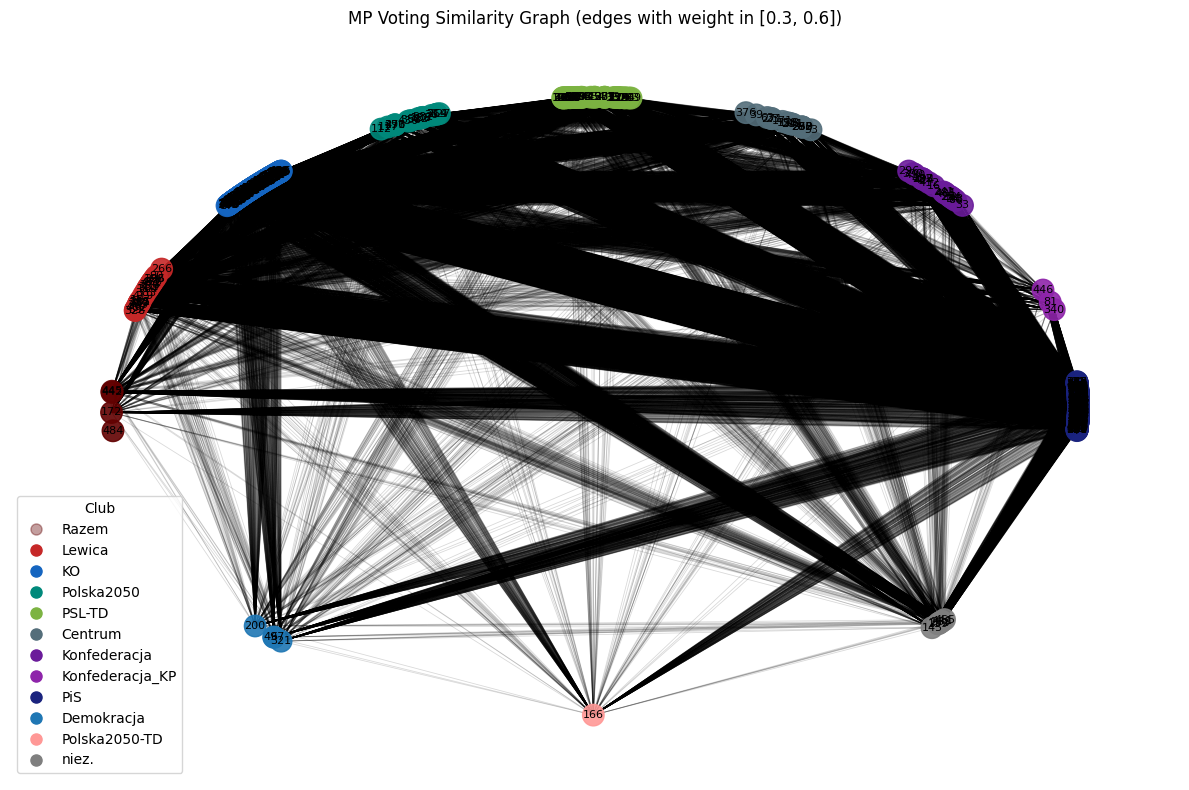

In [22]:
plot_graph_by_club(
    G,
    clubs_ordered=CLUBS_ORDERED,
    node_size=240,
    jitter=0.08,
    
    seed=7,
    show_node_ids=True,
    node_id_font_size=8,
    title=f"MP Voting Similarity Graph (edges with weight in [{THRESHOLD_DOWN}, {THRESHOLD_UP}])",
)
